# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Bintan Nabilah Faradisa
- **Email:** nabilabintan664@gmail.com
- **ID Dicoding:** CDCC266D6X2677

## Menentukan Pertanyaan Bisnis

- jam berapa saja dalam sehari yang memiliki tingkat penyewaan sepeda tertinggi dan terendah, serta bagaimana perbandingan pola antara pengguna casual dan registered berdasarkan data tahun 2011-2012
- bagaimana pengaruh kondisi cuaca terhadap julah penyewaan sepeda, dan apakah terdapat hari-hari tertentu dengan penyewaan sangat rendah (anomali) beserta penyebab berdasarkan data tahun 2011-2012

## Import Semua Packages/Library yang Digunakan

In [4]:
# Import semua library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Semua library berhasil diimport!")

from google.colab import files
uploaded = files.upload()

Semua library berhasil diimport!


Saving day.csv to day.csv
Saving hour.csv to hour.csv


## Data Wrangling

### Gathering Data

In [5]:
# Load data per jam (hour.csv)
hour_df = pd.read_csv('hour.csv')

# Load data per hari (day.csv)
day_df = pd.read_csv('day.csv')

# Tampilkan 5 baris pertama dari masing-masing dataset
print("-"*50)
print("5 BARIS PERTAMA - HOUR DATASET")
print("-"*50)
print(hour_df.head())

print("\n" + "-"*50)
print("5 BARIS PERTAMA - DAY DATASET")
print("-"*50)
print(day_df.head())

print("\n Data berhasil dimuat!")
print(f"Ukuran hour_df: {hour_df.shape[0]} baris x {hour_df.shape[1]} kolom")
print(f"Ukuran day_df: {day_df.shape[0]} baris x {day_df.shape[1]} kolom")

--------------------------------------------------
5 BARIS PERTAMA - HOUR DATASET
--------------------------------------------------
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75     

**Insight:**
- penyewaan sepeda paling rendah pada dini hari (jam 0-4).
- pengguna registered mendominasi dibanding casual.
- cuaca diawal tahun 2011 didominasi kondisi cerah.
- total penyewaan harian fluktuatif, tertinggi 1.600.
- suhu awal januari 2011 cukup dingin (0,19 - 0,36).

### Assessing Data

In [6]:
print("-"*50)
print("INFORMASI TIPE DATA - hour_df")
print("-"*50)
hour_df.info()

print("\n" + "-"*50)
print("CEK MISSING VALUES - hour_df")
print("-"*50)
print(hour_df.isna().sum())

print("\n" + "-"*50)
print("CEK DUPLIKASI DATA - hour_df")
print("-"*50)
print(f"Jumlah baris duplikat: {hour_df.duplicated().sum()}")

print("\n" + "-"*50)
print("STATISTIK DESKRIPTIF - hour_df")
print("-"*50)
print(hour_df.describe())


print("-"*50)
print("INFORMASI TIPE DATA - day_df")
print("-"*50)
day_df.info()

print("\n" + "-"*50)
print("CEK MISSING VALUES - day_df")
print("-"*50)
print(day_df.isna().sum())

print("\n" + "-"*50)
print("CEK DUPLIKASI DATA - day_df")
print("-"*50)
print(f"Jumlah baris duplikat: {day_df.duplicated().sum()}")

print("\n" + "-"*50)
print("STATISTIK DESKRIPTIF - day_df")
print("-"*50)
print(day_df.describe())

--------------------------------------------------
INFORMASI TIPE DATA - hour_df
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         1737

**Insight:**
- tidak ada missing values dan duplikasi data.
- kolom dteday harusnya diubah ke datetime.
- kolom season, hr, weekday dll harus diubah ke category.
- rata-rata penyewaan per jam : 189 sepeda.
- rata-rata penyewaan per hari : 4.504 sepeda.
- pengguna registered mendominasi dibanding casual.

### Cleaning Data

In [7]:
# 1. Mengubah kolom dteday menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mengubah kolom kategorikal menjadi category
categorical_columns = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

for col in categorical_columns:
    hour_df[col] = hour_df[col].astype('category')

# 3. Verifikasi perubahan tipe data
print("-"*50)
print("TIPE DATA SETELAH CLEANING - hour_df")
print("-"*50)
print(hour_df.dtypes)

print("\n" + "-"*50)
print("KONFIRMASI MISSING VALUES - hour_df")
print("-"*50)
print(hour_df.isna().sum())


# 1. Mengubah kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# 2. Mengubah kolom kategorikal menjadi category
categorical_columns_day = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

for col in categorical_columns_day:
    day_df[col] = day_df[col].astype('category')

# 3. Verifikasi perubahan tipe data
print("-"*50)
print("TIPE DATA SETELAH CLEANING - day_df")
print("-"*50)
print(day_df.dtypes)

print("\n" + "-"*50)
print("KONFIRMASI MISSING VALUES - day_df")
print("-"*50)
print(day_df.isna().sum())

--------------------------------------------------
TIPE DATA SETELAH CLEANING - hour_df
--------------------------------------------------
instant                int64
dteday        datetime64[ns]
season              category
yr                  category
mnth                category
hr                  category
holiday             category
weekday             category
workingday          category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

--------------------------------------------------
KONFIRMASI MISSING VALUES - hour_df
--------------------------------------------------
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspe

**Insight:**
- tipe data sudah sesuai : dteday menjadi datetime, kolom kategori menjadi category
- tidak ada missing values (semua kolom bersih)
- data siap dianalisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [8]:
# 1. Rangkuman statistik
print("-"*50)
print("RANGKUMAN STATISTIK - hour_df")
print("-"*50)
print(hour_df.describe(include="all"))

# 2. Rata-rata penyewaan per jam (ditambah observed=True)
print("\n" + "-"*50)
print("RATA-RATA PENYEWAAN PER JAM")
print("-"*50)
print(hour_df.groupby(by="hr", observed=True).agg({
    "cnt": ["mean", "max", "min"],
    "casual": "mean",
    "registered": "mean"
}))

# 3. Rata-rata penyewaan per musim (ditambah observed=True)
print("\n" + "-"*50)
print("RATA-RATA PENYEWAAN PER MUSIM")
print("-"*50)
print(hour_df.groupby(by="season", observed=True).agg({
    "cnt": ["mean", "max", "min"]
}))

# 4. Rangkuman statistik day_df
print("-"*50)
print("RANGKUMAN STATISTIK - day_df")
print("-"*50)
print(day_df.describe(include="all"))

# 5. Penyewaan per bulan (ditambah observed=True)
print("\n" + "-"*50)
print("TOTAL PENYEWAAN PER BULAN")
print("-"*50)
print(day_df.groupby(by="mnth", observed=True).agg({
    "cnt": ["sum", "mean", "max"]
}))

# 6. Penyewaan per tahun (ditambah observed=True)
print("\n" + "-"*50)
print("PERBANDINGAN PENYEWAAN 2011 vs 2012")
print("-"*50)
print(day_df.groupby(by="yr", observed=True).agg({
    "cnt": ["sum", "mean"]
}))

--------------------------------------------------
RANGKUMAN STATISTIK - hour_df
--------------------------------------------------
           instant                         dteday   season       yr     mnth  \
count   17379.0000                          17379  17379.0  17379.0  17379.0   
unique         NaN                            NaN      4.0      2.0     12.0   
top            NaN                            NaN      3.0      1.0      7.0   
freq           NaN                            NaN   4496.0   8734.0   1488.0   
mean     8690.0000  2012-01-02 04:08:34.552045568      NaN      NaN      NaN   
min         1.0000            2011-01-01 00:00:00      NaN      NaN      NaN   
25%      4345.5000            2011-07-04 00:00:00      NaN      NaN      NaN   
50%      8690.0000            2012-01-02 00:00:00      NaN      NaN      NaN   
75%     13034.5000            2012-07-02 00:00:00      NaN      NaN      NaN   
max     17379.0000            2012-12-31 00:00:00      NaN      NaN 

**Insight:**
- rata-rata penyewaan per jam: 189 sepeda.
- jam tersibuk : 17.00-18.00 (rata-rata 461 sepeda)
-jam tersepi : 04.00 (rata-rata 6 sepeda)
- musim gugur (fall) paling ramai, musim semi (spring) paling sepi
- pengguna registed mendominasi dibanding casual
- bulan september paling tinggi penyewaannya, januari paling rendah
- tahun 2012 lebih tinggi 64% dibanding 2011

## Visualization & Explanatory Analysis

### Pertanyaan 1:

------------------------------------------------------------
JAWABAN PERTANYAAN 1
------------------------------------------------------------

1. RATA-RATA PENYEWAAN PER JAM:
----------------------------------------
       cnt  casual  registered
hr                            
0    53.90   10.16       43.74
1    33.38    6.50       26.87
2    22.87    4.77       18.10
3    11.73    2.72        9.01
4     6.35    1.25        5.10
5    19.89    1.41       18.48
6    76.04    4.16       71.88
7   212.06   11.06      201.01
8   359.01   21.68      337.33
9   219.31   30.89      188.42
10  173.67   46.48      127.19
11  208.14   59.54      148.60
12  253.32   68.29      185.02
13  253.66   72.31      181.35
14  240.95   75.57      165.38
15  251.23   74.91      176.33
16  311.98   73.75      238.24
17  461.45   74.27      387.18
18  425.51   61.12      364.39
19  311.52   48.77      262.75
20  226.03   36.23      189.80
21  172.31   28.26      144.06
22  131.34   22.25      109.08
23   87.

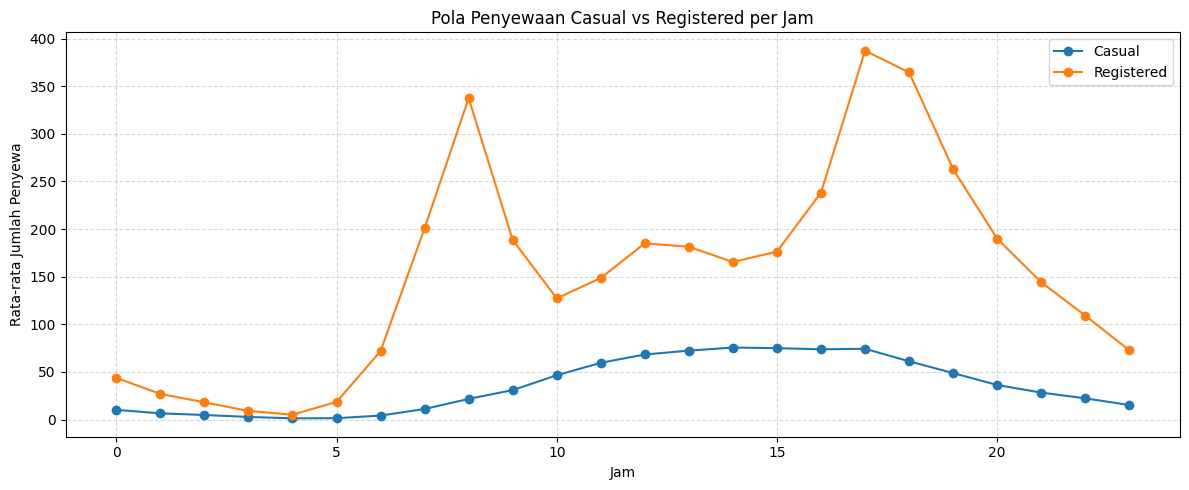

In [9]:
print("-"*60)
print("JAWABAN PERTANYAAN 1")
print("-"*60)

# 1. Rata-rata penyewaan per jam
print("\n1. RATA-RATA PENYEWAAN PER JAM:")
print("-"*40)
print(hour_df.groupby(by="hr", observed=True).agg({
    "cnt": "mean",
    "casual": "mean",
    "registered": "mean"
}).round(2))

# 2. 5 Jam dengan penyewaan tertinggi
print("\n2. 5 JAM DENGAN PENYEWAAN TERTINGGI:")
print("-"*40)
print(hour_df.groupby(by="hr", observed=True).agg({
    "cnt": "mean"
}).sort_values(by="cnt", ascending=False).head(5).round(2))

# 3. Pola casual vs registered per jam
print("\n3. PERBANDINGAN CASUAL vs REGISTERED PER JAM:")
print("-"*40)
hour_df.groupby(by="hr", observed=True).agg({
    "casual": "mean",
    "registered": "mean"
}).round(2).plot(kind='line', figsize=(12,5), marker='o')
plt.title("Pola Penyewaan Casual vs Registered per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Jumlah Penyewa")
plt.legend(["Casual", "Registered"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

------------------------------------------------------------
JAWABAN PERTANYAAN 2
------------------------------------------------------------

1. RATA-RATA PENYEWAAN BERDASARKAN CUACA:
----------------------------------------
               cnt         
              mean min  max
weathersit                 
1           204.87   1  977
2           175.17   1  957
3           111.58   1  891
4            74.33  23  164

2. VISUALISASI PENGARUH CUACA:
----------------------------------------


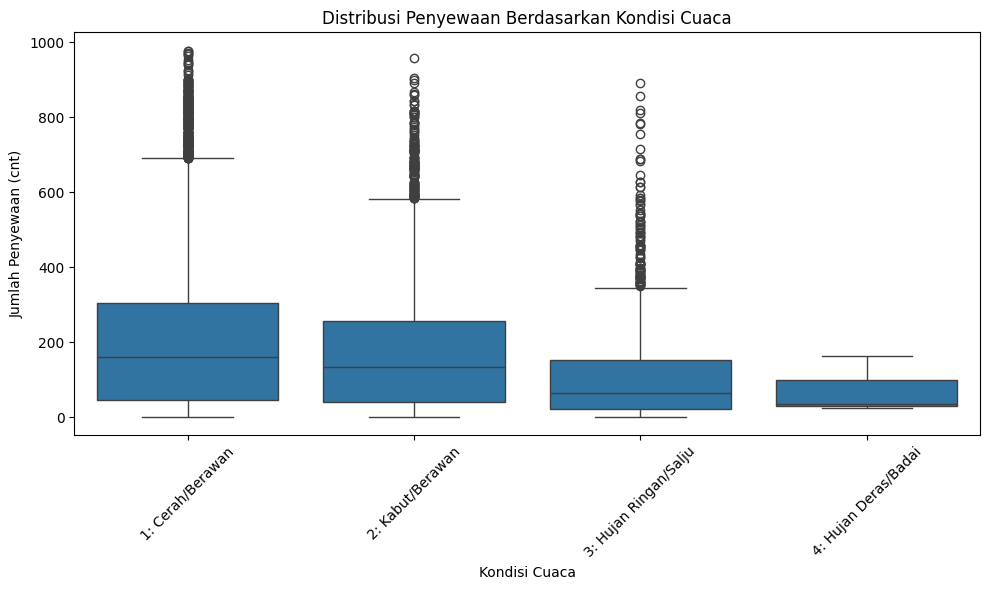


3. DETEKSI ANOMALI (HARI DENGAN PENYEWAAN TERENDAH):
----------------------------------------
10 Hari dengan Penyewaan Terendah:
        dteday  cnt
667 2012-10-29   22
26  2011-01-27  431
725 2012-12-26  441
25  2011-01-26  506
64  2011-03-06  605
68  2011-03-10  623
301 2011-10-29  627
17  2011-01-18  683
340 2011-12-07  705
358 2011-12-25  754

4. CEK ANOMALI HURRICANE SANDY (Oktober 2012):
----------------------------------------
        dteday   cnt weathersit      temp
666 2012-10-28  4459          2  0.477500
667 2012-10-29    22          3  0.440000
668 2012-10-30  1096          2  0.318182
669 2012-10-31  5566          2  0.357500


In [10]:
print("-"*60)
print("JAWABAN PERTANYAAN 2")
print("-"*60)

# 1. Rata-rata penyewaan berdasarkan kondisi cuaca
print("\n1. RATA-RATA PENYEWAAN BERDASARKAN CUACA:")
print("-"*40)

weather_map = {
    1: '1: Cerah/Berawan',
    2: '2: Kabut/Berawan',
    3: '3: Hujan Ringan/Salju',
    4: '4: Hujan Deras/Badai'
}
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

print(hour_df.groupby(by="weathersit", observed=True).agg({
    "cnt": ["mean", "min", "max"]
}).round(2))

# 2. Visualisasi pengaruh cuaca
print("\n2. VISUALISASI PENGARUH CUACA:")
print("-"*40)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=hour_df, x='weather_label', y='cnt')
plt.title("Distribusi Penyewaan Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan (cnt)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Deteksi anomali (hari dengan penyewaan sangat rendah)
print("\n3. DETEKSI ANOMALI (HARI DENGAN PENYEWAAN TERENDAH):")
print("-"*40)

# Agregasi per hari
daily_rental = day_df[['dteday', 'cnt']].copy()
daily_rental = daily_rental.sort_values('cnt').head(10)

print("10 Hari dengan Penyewaan Terendah:")
print(daily_rental)

# 4. Cek apakah ada anomali dari Hurricane Sandy (Oktober 2012)
print("\n4. CEK ANOMALI HURRICANE SANDY (Oktober 2012):")
print("-"*40)
sandy_period = day_df[(day_df['dteday'] >= '2012-10-28') & (day_df['dteday'] <= '2012-10-31')]
print(sandy_period[['dteday', 'cnt', 'weathersit', 'temp']])

**Insight:**

pertanyaan 1:
- jam tersibuk 17.00 (461 sepeda/jam), 18.00 (426), dan 08.00 (359)
- jam tersepi 04.00 (hanya 6 sepeda/jam)
- pengguna registed mendominasi jam 07.00-09.00 dan 17.00-18.00 (jam komuter)
- penngguna casual lebih banyak di siang hari (12.00-16.00)


pertanyaan 2 :
- cuaca cerah rata-rata 205 sepeda/jam
- cuaca hujan ringan turun jadi 112 sepeda/jam
- cuaca hujan deras hanya 74 sepeda/jam
- anomali terdeteksi 29 oktober 2012 penyewaan hanya 22 sepeda (hurricane sandy)

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1
- Conclution pertanyaan 2